# 05 - Advanced Models

## Objective

The purpose of this notebook is to train, tune, and evaluate an advanced gradient boosting model for predicting California home sale prices.

In this notebook, we will:

- Load the cleaned training, validation, and testing datasets created during preprocessing.
- Train multiple XGBoost Regression configurations.
- Perform light hyperparameter tuning by adjusting the number of boosting rounds, maximum tree depth, and learning rate.
- Compare candidate configurations using the validation dataset.
- Select the strongest XGBoost configuration without using the final testing dataset for model-selection decisions.
- Retrain the selected configuration using the combined training and validation data.
- Evaluate the final XGBoost model on the untouched testing dataset.
- Compare its final performance with Linear Regression, Decision Tree, and Random Forest.

This workflow allows hyperparameter tuning to be performed using the validation period while preserving the testing period for final model evaluation.

In [1]:
# ============================================
# Import required libraries
# ============================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)

# Display all columns when inspecting DataFrames
pd.set_option("display.max_columns", None)

## Load the Cleaned Datasets

The preprocessing notebook produced separate training, validation, and testing datasets.

These datasets serve different purposes during advanced model development:

- **Training set** – Used to train each candidate XGBoost configuration.
- **Validation set** – Used to compare hyperparameter configurations and select the strongest model.
- **Testing set** – Reserved for final evaluation after the XGBoost configuration has been selected.

This separation prevents the final testing period from influencing hyperparameter tuning.

In [2]:
# ============================================
# Load the cleaned datasets
# ============================================

data_path = Path("../data")

train = pd.read_csv(
    data_path / "train_cleaned.csv"
)

validation = pd.read_csv(
    data_path / "validation_cleaned.csv"
)

test = pd.read_csv(
    data_path / "test_cleaned.csv"
)

print("Datasets loaded successfully!\n")

print(f"Training shape:   {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Testing shape:    {test.shape}")

Datasets loaded successfully!

Training shape:   (324378, 104)
Validation shape: (11901, 104)
Testing shape:    (12710, 104)


## Inspect the Datasets

Before training the advanced models, we'll briefly inspect the training dataset to confirm that the processed features loaded correctly.

In [3]:
# Display the first few rows of the training dataset
train.head()

,ClosePrice,Latitude,Longitude,LivingArea,ParkingTotal,LotSizeAcres,StreetNumberNumeric,BathroomsTotalInteger,BedroomsTotal,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,PropertyAge,BathroomBedroomRatio,LivingAreaPerBedroom,LotSizePerLivingArea,DistrictName_TE,ViewYN_True,PoolPrivateYN_True,AttachedGarageYN_True,FireplaceYN_True,NewConstructionYN_True,"Levels_MultiSplit,One",Levels_One,"Levels_One,MultiSplit","Levels_One,ThreeOrMore","Levels_One,Two","Levels_One,Two,MultiSplit","Levels_One,Two,ThreeOrMore","Levels_One,Two,ThreeOrMore,MultiSplit",Levels_ThreeOrMore,"Levels_ThreeOrMore,MultiSplit","Levels_ThreeOrMore,One",Levels_Two,"Levels_Two,MultiSplit","Levels_Two,MultiSplit,One","Levels_Two,One","Levels_Two,ThreeOrMore","Levels_Two,ThreeOrMore,MultiSplit",CountyOrParish_Alpine,CountyOrParish_Amador,CountyOrParish_Butte,CountyOrParish_Calaveras,CountyOrParish_Clark,CountyOrParish_Colusa,CountyOrParish_Contra Costa,CountyOrParish_Del Norte,CountyOrParish_El Dorado,CountyOrParish_Foreign Country,CountyOrParish_Fresno,CountyOrParish_Glenn,CountyOrParish_Humboldt,CountyOrParish_Imperial,CountyOrParish_Inyo,CountyOrParish_Kern,CountyOrParish_Kings,CountyOrParish_Lake,CountyOrParish_Lassen,CountyOrParish_Los Angeles,CountyOrParish_Madera,CountyOrParish_Marin,CountyOrParish_Mariposa,CountyOrParish_Mendocino,CountyOrParish_Merced,CountyOrParish_Modoc,CountyOrParish_Mono,CountyOrParish_Monterey,CountyOrParish_Napa,CountyOrParish_Nevada,CountyOrParish_Orange,CountyOrParish_Other,CountyOrParish_Other County,CountyOrParish_Other State,CountyOrParish_Placer,CountyOrParish_Plumas,CountyOrParish_Riverside,CountyOrParish_Sacramento,CountyOrParish_San Benito,CountyOrParish_San Bernardino,CountyOrParish_San Diego,CountyOrParish_San Francisco,CountyOrParish_San Joaquin,CountyOrParish_San Luis Obispo,CountyOrParish_San Mateo,CountyOrParish_Santa Barbara,CountyOrParish_Santa Clara,CountyOrParish_Santa Cruz,CountyOrParish_Shasta,CountyOrParish_Sierra,CountyOrParish_Siskiyou,CountyOrParish_Solano,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba
0,535000.0,-0.478192,0.144443,-0.704117,-0.025460,-0.002593,-0.002885,-0.523580,0.554565,-0.664176,-0.020789,0.235535,-0.001184,-0.279119,-0.017319,-0.000611,-0.854960,-1.253110,-0.016702,0.474971,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,820000.0,-1.203340,0.521160,-0.039649,0.023670,-0.002591,-0.035723,1.228924,0.554565,1.505626,-0.019578,0.070065,-0.001184,-0.279119,-0.017255,-1.787041,0.845448,-0.429656,-0.016758,-0.348396,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,853800.0,-1.203317,0.521232,-0.039649,-0.025460,-0.002591,-0.035740,1.228924,0.554565,1.505626,-0.019578,0.070065,-0.001184,-0.279119,-0.017255,-1.787041,0.845448,-0.429656,-0.016758,-0.345082,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,565000.0,-0.143176,0.236578,0.413978,-0.025460,-0.002537,-0.006869,0.352672,0.554565,-0.664176,0.031414,0.235535,-0.001184,-0.279119,-0.014982,-1.203717,-0.004756,0.132509,-0.015188,-1.041485,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1975000.0,-0.714388,0.545489,3.455196,0.048234,-0.002458,0.130925,3.857680,2.671151,-0.664176,-0.030681,0.235535,0.805388,-0.279119,-0.011644,-1.750583,1.412250,1.589389,-0.015178,-0.556501,1,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

## Separate the Features and Target

Machine learning models use one variable as the value they are trying to predict, while all remaining variables are used to help make that prediction.

For this project:

- **ClosePrice** is the target variable because it represents the home's final sale price.
- All remaining columns will be used as predictor variables.

In [4]:
# ============================================
# Separate predictor variables and target
# ============================================

# Training data
X_train = train.drop(columns="ClosePrice")
y_train = train["ClosePrice"]

# Validation data
X_validation = validation.drop(columns="ClosePrice")
y_validation = validation["ClosePrice"]

# Testing data
X_test = test.drop(columns="ClosePrice")
y_test = test["ClosePrice"]

print(f"Training features:   {X_train.shape}")
print(f"Validation features: {X_validation.shape}")
print(f"Testing features:    {X_test.shape}")

print()

print(f"Training target:     {y_train.shape}")
print(f"Validation target:   {y_validation.shape}")
print(f"Testing target:      {y_test.shape}")

Training features:   (324378, 103)
Validation features: (11901, 103)
Testing features:    (12710, 103)

Training target:     (324378,)
Validation target:   (11901,)
Testing target:      (12710,)


## Why XGBoost?

Extreme Gradient Boosting (XGBoost) is an advanced machine learning algorithm that builds a sequence of decision trees, where each new tree focuses on correcting the prediction errors made by the previous trees.

Unlike Random Forest, which builds many independent trees and averages their predictions, XGBoost builds trees one at a time so that each successive tree improves upon the previous model. This boosting approach often produces more accurate predictions while controlling overfitting through regularization and other optimization techniques.

Because of its strong predictive performance and efficiency, XGBoost is widely used in machine learning competitions and real-world regression problems, making it a natural next step for predicting California home sale prices.

## XGBoost Hyperparameter Tuning

Week 7 requires light hyperparameter tuning of the XGBoost model.

Three important XGBoost hyperparameters are explored:

- **`n_estimators`** – The number of boosting trees built by the model.
- **`max_depth`** – The maximum depth of each individual tree.
- **`learning_rate`** – The amount each new tree contributes to correcting previous prediction errors.

The candidate configurations are trained using the training dataset and compared using the validation dataset. The testing dataset is not used during this tuning stage.

## Train XGBoost Version A

Version A provides the starting configuration for the tuning process.

It uses 100 boosting trees, a maximum tree depth of 6, and a learning rate of 0.3. Later configurations will adjust these values to determine whether model performance improves.

In [7]:
# ============================================
# Train XGBoost Version A
# ============================================

xgb_a = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.3,
    random_state=42,
    n_jobs=-1
)

xgb_a.fit(
    X_train,
    y_train
)

print("XGBoost Version A trained successfully!")

XGBoost Version A trained successfully!


In [8]:
# ============================================
# Generate Version A validation predictions
# ============================================

xgb_a_validation_predictions = xgb_a.predict(
    X_validation
)

In [9]:
# ============================================
# Calculate Version A validation metrics
# ============================================

xgb_a_validation_mae = mean_absolute_error(
    y_validation,
    xgb_a_validation_predictions
)

xgb_a_validation_rmse = root_mean_squared_error(
    y_validation,
    xgb_a_validation_predictions
)

xgb_a_validation_r2 = r2_score(
    y_validation,
    xgb_a_validation_predictions
)

xgb_a_validation_mape = mean_absolute_percentage_error(
    y_validation,
    xgb_a_validation_predictions
) * 100

xgb_a_validation_mdape = np.median(
    np.abs(
        (y_validation - xgb_a_validation_predictions) /
        y_validation
    )
) * 100

print("XGBoost Version A Validation Performance\n")

print(f"MAE:   ${xgb_a_validation_mae:,.2f}")
print(f"RMSE:  ${xgb_a_validation_rmse:,.2f}")
print(f"R²:    {xgb_a_validation_r2:.4f}")
print(f"MAPE:  {xgb_a_validation_mape:.2f}%")
print(f"MdAPE: {xgb_a_validation_mdape:.2f}%")

XGBoost Version A Validation Performance

MAE:   $179,693.07
RMSE:  $332,111.04
R²:    0.8852
MAPE:  13.77%
MdAPE: 9.79%


## Train XGBoost Version B

Version B tests whether increasing the number of boosting trees improves model performance.

The number of estimators is increased from **100 to 200**, while `max_depth` and `learning_rate` remain unchanged from Version A.

This allows the effect of additional boosting rounds to be evaluated independently using the validation dataset.

In [10]:
# ============================================
# Train XGBoost Version B
# ============================================

xgb_b = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.3,
    random_state=42,
    n_jobs=-1
)

# Train Version B using only the training data.
xgb_b.fit(
    X_train,
    y_train
)

print("XGBoost Version B trained successfully!")

XGBoost Version B trained successfully!


In [11]:
# ============================================
# Generate Version B validation predictions
# ============================================

xgb_b_validation_predictions = xgb_b.predict(
    X_validation
)

In [12]:
# ============================================
# Calculate Version B validation metrics
# ============================================

xgb_b_validation_mae = mean_absolute_error(
    y_validation,
    xgb_b_validation_predictions
)

xgb_b_validation_rmse = root_mean_squared_error(
    y_validation,
    xgb_b_validation_predictions
)

xgb_b_validation_r2 = r2_score(
    y_validation,
    xgb_b_validation_predictions
)

xgb_b_validation_mape = mean_absolute_percentage_error(
    y_validation,
    xgb_b_validation_predictions
) * 100

xgb_b_validation_mdape = np.median(
    np.abs(
        (y_validation - xgb_b_validation_predictions) /
        y_validation
    )
) * 100

print("XGBoost Version B Validation Performance\n")

print(f"MAE:   ${xgb_b_validation_mae:,.2f}")
print(f"RMSE:  ${xgb_b_validation_rmse:,.2f}")
print(f"R²:    {xgb_b_validation_r2:.4f}")
print(f"MAPE:  {xgb_b_validation_mape:.2f}%")
print(f"MdAPE: {xgb_b_validation_mdape:.2f}%")

XGBoost Version B Validation Performance

MAE:   $171,698.71
RMSE:  $321,262.13
R²:    0.8926
MAPE:  13.12%
MdAPE: 9.24%


## Train XGBoost Version C

Version C tests whether allowing each boosting tree to model more complex relationships improves predictive performance.

The number of estimators remains at **200**, while `max_depth` is increased from **6 to 8**. The learning rate remains unchanged at **0.3**.

Increasing tree depth allows the model to capture more detailed interactions among property characteristics, although deeper trees may also increase the risk of overfitting.

In [13]:
# ============================================
# Train XGBoost Version C
# ============================================

xgb_c = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.3,
    random_state=42,
    n_jobs=-1
)

# Train Version C using only the training data.
xgb_c.fit(
    X_train,
    y_train
)

print("XGBoost Version C trained successfully!")

XGBoost Version C trained successfully!


In [14]:
# ============================================
# Generate Version C validation predictions
# ============================================

xgb_c_validation_predictions = xgb_c.predict(
    X_validation
)

In [15]:
# ============================================
# Calculate Version C validation metrics
# ============================================

xgb_c_validation_mae = mean_absolute_error(
    y_validation,
    xgb_c_validation_predictions
)

xgb_c_validation_rmse = root_mean_squared_error(
    y_validation,
    xgb_c_validation_predictions
)

xgb_c_validation_r2 = r2_score(
    y_validation,
    xgb_c_validation_predictions
)

xgb_c_validation_mape = mean_absolute_percentage_error(
    y_validation,
    xgb_c_validation_predictions
) * 100

xgb_c_validation_mdape = np.median(
    np.abs(
        (y_validation - xgb_c_validation_predictions) /
        y_validation
    )
) * 100

print("XGBoost Version C Validation Performance\n")

print(f"MAE:   ${xgb_c_validation_mae:,.2f}")
print(f"RMSE:  ${xgb_c_validation_rmse:,.2f}")
print(f"R²:    {xgb_c_validation_r2:.4f}")
print(f"MAPE:  {xgb_c_validation_mape:.2f}%")
print(f"MdAPE: {xgb_c_validation_mdape:.2f}%")

XGBoost Version C Validation Performance

MAE:   $164,495.31
RMSE:  $318,158.27
R²:    0.8947
MAPE:  12.34%
MdAPE: 8.44%


## Train XGBoost Version D

Version D evaluates a lower learning rate.

The `learning_rate` is reduced from **0.3 to 0.1**, allowing each individual boosting tree to make a smaller adjustment to the model's predictions.

Because a lower learning rate generally requires more boosting rounds, `n_estimators` is increased to **300**, while `max_depth` remains at **8**.

This configuration tests whether slower, more gradual boosting improves generalization to the validation dataset.

In [16]:
# ============================================
# Train XGBoost Version D
# ============================================

xgb_d = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train Version D using only the training data.
xgb_d.fit(
    X_train,
    y_train
)

print("XGBoost Version D trained successfully!")

XGBoost Version D trained successfully!


In [17]:
# ============================================
# Generate Version D validation predictions
# ============================================

xgb_d_validation_predictions = xgb_d.predict(
    X_validation
)

In [18]:
# ============================================
# Calculate Version D validation metrics
# ============================================

xgb_d_validation_mae = mean_absolute_error(
    y_validation,
    xgb_d_validation_predictions
)

xgb_d_validation_rmse = root_mean_squared_error(
    y_validation,
    xgb_d_validation_predictions
)

xgb_d_validation_r2 = r2_score(
    y_validation,
    xgb_d_validation_predictions
)

xgb_d_validation_mape = mean_absolute_percentage_error(
    y_validation,
    xgb_d_validation_predictions
) * 100

xgb_d_validation_mdape = np.median(
    np.abs(
        (y_validation - xgb_d_validation_predictions) /
        y_validation
    )
) * 100

print("XGBoost Version D Validation Performance\n")

print(f"MAE:   ${xgb_d_validation_mae:,.2f}")
print(f"RMSE:  ${xgb_d_validation_rmse:,.2f}")
print(f"R²:    {xgb_d_validation_r2:.4f}")
print(f"MAPE:  {xgb_d_validation_mape:.2f}%")
print(f"MdAPE: {xgb_d_validation_mdape:.2f}%")

XGBoost Version D Validation Performance

MAE:   $163,227.38
RMSE:  $314,597.09
R²:    0.8970
MAPE:  12.19%
MdAPE: 8.39%


## Compare XGBoost Validation Performance

The four XGBoost configurations are compared using the validation dataset.

Because the validation period is separate from the final testing period, these results can be used to select the strongest hyperparameter configuration without allowing the testing data to influence model-selection decisions.

The configurations differ in the number of boosting trees, maximum tree depth, and learning rate.

In [19]:
# ============================================
# Compare XGBoost validation performance
# ============================================

xgb_validation_comparison = pd.DataFrame({
    "Version": [
        "A",
        "B",
        "C",
        "D"
    ],
    "n_estimators": [
        100,
        200,
        200,
        300
    ],
    "max_depth": [
        6,
        6,
        8,
        8
    ],
    "learning_rate": [
        0.3,
        0.3,
        0.3,
        0.1
    ],
    "MAE": [
        xgb_a_validation_mae,
        xgb_b_validation_mae,
        xgb_c_validation_mae,
        xgb_d_validation_mae
    ],
    "RMSE": [
        xgb_a_validation_rmse,
        xgb_b_validation_rmse,
        xgb_c_validation_rmse,
        xgb_d_validation_rmse
    ],
    "R²": [
        xgb_a_validation_r2,
        xgb_b_validation_r2,
        xgb_c_validation_r2,
        xgb_d_validation_r2
    ],
    "MAPE": [
        xgb_a_validation_mape,
        xgb_b_validation_mape,
        xgb_c_validation_mape,
        xgb_d_validation_mape
    ],
    "MdAPE": [
        xgb_a_validation_mdape,
        xgb_b_validation_mdape,
        xgb_c_validation_mdape,
        xgb_d_validation_mdape
    ]
})

xgb_validation_comparison.style.format({
    "learning_rate": "{:.1f}",
    "MAE": "${:,.2f}",
    "RMSE": "${:,.2f}",
    "R²": "{:.4f}",
    "MAPE": "{:.2f}%",
    "MdAPE": "{:.2f}%"
}).hide(axis="index")

Version,n_estimators,max_depth,learning_rate,MAE,RMSE,R²,MAPE,MdAPE
A,100,6,0.3,"$179,693.07","$332,111.04",0.8852,13.77%,9.79%
B,200,6,0.3,"$171,698.71","$321,262.13",0.8926,13.12%,9.24%
C,200,8,0.3,"$164,495.31","$318,158.27",0.8947,12.34%,8.44%
D,300,8,0.1,"$163,227.38","$314,597.09",0.8970,12.19%,8.39%


### Hyperparameter Tuning Results

The validation results show a consistent improvement across the four XGBoost configurations.

Increasing `n_estimators` from 100 in Version A to 200 in Version B improved all five evaluation metrics, suggesting that additional boosting rounds allowed the model to capture more predictive structure.

Version C retained 200 estimators but increased `max_depth` from 6 to 8. This produced another improvement, indicating that deeper trees were better able to capture complex relationships and interactions among the property features.

Version D reduced the `learning_rate` from 0.3 to 0.1 while increasing `n_estimators` to 300. This configuration produced the strongest validation performance across all five metrics, achieving an **R² of 0.8970**, **MAE of $163,227**, **RMSE of $314,597**, **MAPE of 12.19%**, and **MdAPE of 8.39%**.

Based on these validation results, **Version D is selected as the final XGBoost configuration**.

## Prepare the Final Training Dataset

After selecting Version D using the validation results, the training and validation datasets are combined.

This allows the final XGBoost model to use all available development data before evaluation on the untouched testing period.

The selected hyperparameters remain unchanged so that the testing dataset does not influence model configuration.

In [20]:
# ============================================
# Combine training and validation data
# ============================================

X_train_final = pd.concat(
    [X_train, X_validation],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_validation],
    ignore_index=True
)

print(
    f"Final training features: "
    f"{X_train_final.shape}"
)

print(
    f"Final training target: "
    f"{y_train_final.shape}"
)

Final training features: (336279, 103)
Final training target: (336279,)


## Train the Final XGBoost Model

Version D produced the strongest validation performance and is therefore selected as the final XGBoost configuration.

The selected model uses:

- **300 estimators**
- **Maximum tree depth of 8**
- **Learning rate of 0.1**

The model is retrained using the combined training and validation data before final evaluation on the testing dataset.

In [21]:
# ============================================
# Train the final XGBoost model
# ============================================

final_xgb = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_train_final,
    y_train_final
)

print("Final XGBoost model trained successfully!")

Final XGBoost model trained successfully!


## Generate Final Test Predictions

After hyperparameter selection was completed using the validation dataset, the final XGBoost model is evaluated on the testing period.

The testing data was not used to select the XGBoost configuration, allowing these results to provide a final estimate of the model's predictive performance.

In [22]:
# ============================================
# Generate final XGBoost test predictions
# ============================================

xgb_test_predictions = final_xgb.predict(
    X_test
)

print(
    f"Generated {len(xgb_test_predictions):,} "
    f"final XGBoost test predictions."
)

Generated 12,710 final XGBoost test predictions.


In [23]:
# ============================================
# Calculate final XGBoost test metrics
# ============================================

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_predictions
)

xgb_test_rmse = root_mean_squared_error(
    y_test,
    xgb_test_predictions
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_predictions
)

xgb_test_mape = mean_absolute_percentage_error(
    y_test,
    xgb_test_predictions
) * 100

xgb_test_mdape = np.median(
    np.abs(
        (y_test - xgb_test_predictions) /
        y_test
    )
) * 100

print("Final XGBoost Test Performance\n")

print(
    f"Mean Absolute Error (MAE): "
    f"${xgb_test_mae:,.2f}"
)

print(
    f"Root Mean Square Error (RMSE): "
    f"${xgb_test_rmse:,.2f}"
)

print(f"R-squared (R²): {xgb_test_r2:.4f}")

print(
    f"Mean Absolute Percentage Error (MAPE): "
    f"{xgb_test_mape:.2f}%"
)

print(
    f"Median Absolute Percentage Error (MdAPE): "
    f"{xgb_test_mdape:.2f}%"
)

Final XGBoost Test Performance

Mean Absolute Error (MAE): $160,177.50
Root Mean Square Error (RMSE): $307,515.58
R-squared (R²): 0.9024
Mean Absolute Percentage Error (MAPE): 12.23%
Median Absolute Percentage Error (MdAPE): 8.46%


## Compare Final Model Performance

The final XGBoost model is compared with the Linear Regression, Decision Tree, and Random Forest models developed in the previous notebooks.

All models are evaluated using the same final testing period and the same five evaluation metrics.

This comparison shows whether the tuned XGBoost model improves upon the earlier modeling approaches.

In [24]:
# ============================================
# Compare final model performance
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        303048.15,
        222391.18,
        173400.42,
        xgb_test_mae
    ],
    "RMSE": [
        503601.63,
        445656.87,
        338823.49,
        xgb_test_rmse
    ],
    "R²": [
        0.7381,
        0.7949,
        0.8815,
        xgb_test_r2
    ],
    "MAPE": [
        27.47,
        16.41,
        13.14,
        xgb_test_mape
    ],
    "MdAPE": [
        20.57,
        10.59,
        8.98,
        xgb_test_mdape
    ]
})

comparison.style.format({
    "MAE": "${:,.2f}",
    "RMSE": "${:,.2f}",
    "R²": "{:.4f}",
    "MAPE": "{:.2f}%",
    "MdAPE": "{:.2f}%"
}).hide(axis="index")

Model,MAE,RMSE,R²,MAPE,MdAPE
Linear Regression,"$303,048.15","$503,601.63",0.7381,27.47%,20.57%
Decision Tree,"$222,391.18","$445,656.87",0.7949,16.41%,10.59%
Random Forest,"$173,400.42","$338,823.49",0.8815,13.14%,8.98%
XGBoost,"$160,177.50","$307,515.58",0.9024,12.23%,8.46%


## Visualize Model Predictions

A scatter plot of the actual and predicted home sale prices provides a visual assessment of the performance of the best-performing XGBoost model.

Points closer to the dashed reference line represent more accurate predictions, while points farther from the line indicate larger prediction errors.

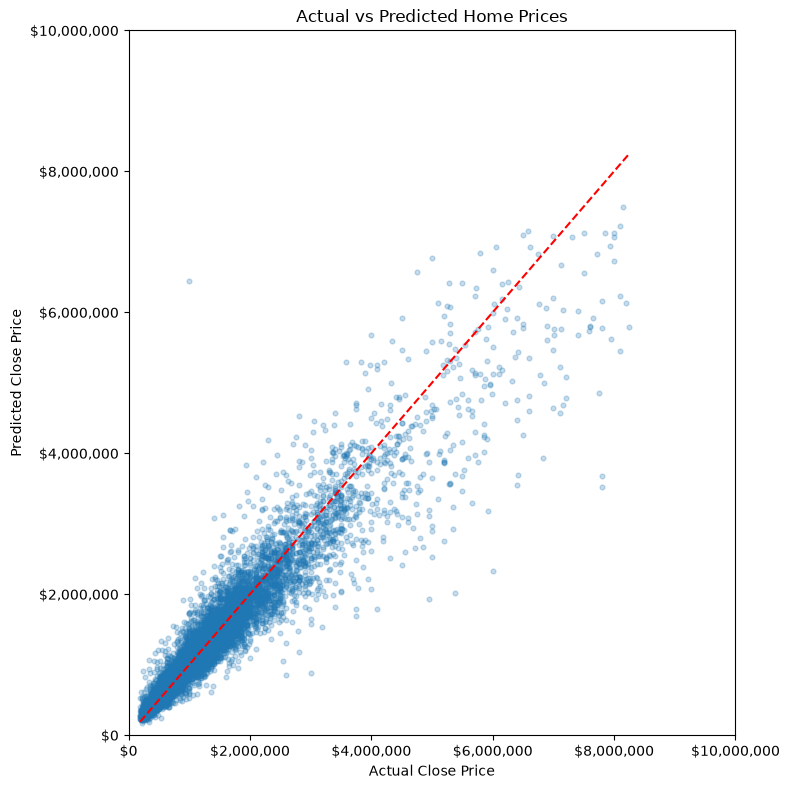

In [25]:
# ============================================
# Compare the model's predicted prices against
# the actual sale prices
# ============================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    xgb_test_predictions,
    alpha=0.25,
    s=12
)

plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Home Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Zoom in to better visualize the vast majority of home sales
limit = 10_000_000

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.tight_layout()
plt.show()

## Interpretation of the Prediction Plot

The scatter plot compares the predicted home sale prices generated by the final XGBoost model with the actual sale prices in the testing dataset.

Points closer to the red dashed reference line indicate more accurate predictions because the predicted sale price closely matches the actual sale price.

The final XGBoost predictions generally cluster closely around the diagonal reference line across most home prices. This visual pattern is consistent with the model's strong numerical evaluation results. The majority of observations are tightly clustered around the reference line, indicating that predicted sale prices closely match the actual sale prices. Some additional variability remains among the highest-priced homes, where prediction errors become larger, but the overall pattern demonstrates a substantial improvement over the earlier models.

## Advanced Model Results

Four XGBoost configurations were evaluated using the validation dataset to perform light hyperparameter tuning.

Version A used 100 estimators, a maximum tree depth of 6, and a learning rate of 0.3. Increasing the number of estimators to 200 in Version B improved all five validation metrics.

Version C retained 200 estimators while increasing the maximum tree depth from 6 to 8, producing another improvement in validation performance.

Version D reduced the learning rate from 0.3 to 0.1 and increased the number of estimators to 300. This configuration achieved the strongest validation performance across all five metrics and was therefore selected as the final XGBoost configuration.

After model selection, Version D was retrained using the combined training and validation data and evaluated on the untouched testing dataset.

The final XGBoost model achieved an **R² of 0.9024**, meaning that it explained approximately **90.2% of the variation in home sale prices in the testing dataset**. It achieved an **MAE of $160,177.50**, **RMSE of $307,515.58**, **MAPE of 12.23%**, and **MdAPE of 8.46%**.

XGBoost achieved the strongest final testing performance across all five evaluation metrics when compared with Linear Regression, Decision Tree, and Random Forest.

## Conclusion

This notebook demonstrated that gradient boosting further improved predictive performance beyond the Linear Regression, Decision Tree, and Random Forest models developed earlier in the project.

Light hyperparameter tuning was performed using a dedicated validation period rather than the final testing data. Increasing the number of estimators, increasing maximum tree depth, and then reducing the learning rate while adding additional boosting rounds progressively improved validation performance.

The strongest configuration used **300 estimators**, a **maximum tree depth of 8**, and a **learning rate of 0.1**.

After retraining this configuration using the combined training and validation data, the final XGBoost model achieved an **R² of 0.9024**, **MAE of $160,177.50**, **RMSE of $307,515.58**, **MAPE of 12.23%**, and **MdAPE of 8.46%** on the testing dataset.

Based on the final testing results, **XGBoost is the strongest predictive model developed in the project so far**.

These results provide the finalized model predictions and performance metrics needed for the expanded evaluation performed in the next stage of the project.

## Summary

In this notebook:

- XGBoost was introduced as an advanced gradient boosting model for predicting California home sale prices.
- Four XGBoost configurations were trained using the training dataset and evaluated using a separate validation period.
- Light hyperparameter tuning explored changes to:
  - `n_estimators`
  - `max_depth`
  - `learning_rate`
- Validation performance improved across Versions A through D.
- Version D achieved the strongest validation performance and was selected as the final XGBoost configuration.
- The selected configuration used:
  - **300 estimators**
  - **Maximum tree depth of 8**
  - **Learning rate of 0.1**
- After model selection, the training and validation datasets were combined and the selected XGBoost configuration was retrained using all available development data.
- The final model was evaluated on the untouched testing dataset.
- XGBoost was compared with the previously developed Linear Regression, Decision Tree, and Random Forest models.

The final XGBoost model achieved:

| Metric | Final Test Performance |
|---|---:|
| MAE | $160,177.50 |
| RMSE | $307,515.58 |
| R² | 0.9024 |
| MAPE | 12.23% |
| MdAPE | 8.46% |

XGBoost achieved the strongest final testing performance among the models developed so far, producing the highest R² and the lowest MAE, RMSE, MAPE, and MdAPE.

These results establish XGBoost as the current best-performing model and provide the finalized model performance needed for the expanded evaluation in the next stage of the project.